# 1. Setup do Ambiente

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

# 2. Carregamento dos Dados

In [2]:
date_fns = pd.read_csv("../logs/method-reconstruction-experiment/date-fns/structured/result.csv")
directus  = pd.read_csv("../logs/method-reconstruction-experiment/directus/structured/result.csv")

df = pd.concat([date_fns, directus], ignore_index=True)

# 3. Limpeza e Tratamento de Dados

In [3]:
for col in ["isTestSuiteSuccessful", "isModelResultCompilable"]:
    df[col] = df[col].map({"true": True, "false": False, True: True, False: False})

df["passRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]
df["testCasePassRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]

df["contextType"] = df["experimentTitle"]
df["model"]       = df["modelName"]
df["permIdx"]     = df["experimentIndex"]
df["totalPerms"]  = df["experimentSize"]

df["subsetSize"]    = df["relevantTestCaseCount"]
df["isFullContext"] = df["contextType"] == "all-relevant-test-case"

# methods = [
#     "areIntervalsOverlapping",
#     "differenceInDays",
#     "differenceInMonths",
#     "eachDayOfInterval",
#     "eachMinuteOfInterval",
#     "authenticateConnection",
#     "createLayoutWrapper",
#     "filterHasNow",
#     "isLoginRedirectAllowed",
#     "useCustomSelection",
# ]

# df = df[df["methodName"].isin(methods)]

print(df.shape)
df.head(3)

(772, 32)


,repositoryName,methodName,methodResolvedFilePath,experimentTitle,experimentDescription,experimentContextItemCount,experimentIndex,experimentSize,experimentContextSlugs,modelSystemPrompt,...,sourceFileWithOriginalMethodBody,sourceFileWithReconstructedMethodBody,passRate,testCasePassRate,contextType,model,permIdx,totalPerms,subsetSize,isFullContext
0,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,all-relevant-test-case,areIntervalsOverlapping > all-relevant-test-ca...,5,1,1,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,"""import { toDate } from \""../toDate/index.ts\""...","""import { toDate } from \""../toDate/index.ts\""...",1.0,1.0,all-relevant-test-case,gemini-2.5-flash,1,1,5,True
1,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,permuted-relevant-test-case,areIntervalsOverlapping > permuted-relevant-te...,5,1,5,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,"""import { toDate } from \""../toDate/index.ts\""...","""import { toDate } from \""../toDate/index.ts\""...",1.0,1.0,permuted-relevant-test-case,gemini-2.5-flash,1,5,5,False
2,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,permuted-relevant-test-case,areIntervalsOverlapping > permuted-relevant-te...,4,2,5,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,"""import { toDate } from \""../toDate/index.ts\""...","""import { toDate } from \""../toDate/index.ts\""...",1.0,1.0,permuted-relevant-test-case,gemini-2.5-flash,2,5,4,False


In [25]:
print("Repositórios:", df["repositoryName"].value_counts().to_dict())
print("Métodos únicos:", df["methodName"].nunique())
print("Modelos:", df["model"].unique())
print("Tipos de contexto:", df["contextType"].unique())

print("\n")
print("Métodos únicos por repositório:")
print(
    df.groupby("repositoryName")["methodName"]
      .nunique()
      .sort_values(ascending=False)
      .to_string()
)

print("\n")
print("Linhas por (modelo, contextType):")
print(df.groupby(["model", "contextType"]).size().to_string())
print("\n")

print("Taxa global de sucesso [test-suite]:", round(df["isTestSuiteSuccessful"].mean(), 4))
print("Taxa global de sucesso [test-case]:", round(df["testCasePassRate"].mean(), 4))
print("Taxa global de compilabilidade:", round(df["isModelResultCompilable"].mean(), 4))

Repositórios: {'date-fns': 532, 'directus': 240}
Métodos únicos: 67
Modelos: ['gemini-2.5-flash' 'gemini-3.0-flash']
Tipos de contexto: ['all-relevant-test-case' 'permuted-relevant-test-case'
 'no-relevant-test-case']


Métodos únicos por repositório:
repositoryName
date-fns    50
directus    17


Linhas por (modelo, contextType):
model             contextType                
gemini-2.5-flash  all-relevant-test-case          67
                  no-relevant-test-case           67
                  permuted-relevant-test-case    252
gemini-3.0-flash  all-relevant-test-case          67
                  no-relevant-test-case           67
                  permuted-relevant-test-case    252


Taxa global de sucesso [test-suite]: 0.3394
Taxa global de sucesso [test-case]: 0.7525
Taxa global de compilabilidade: 0.8264


# 4. Análise Exploratória de Dados

## Análise em Código

In [5]:
CONTEXT_ORDER = ["no-relevant-test-case", "all-relevant-test-case", "permuted-relevant-test-case"]
CONTEXT_LABELS = {
    "no-relevant-test-case":       "Sem testes",
    "all-relevant-test-case":      "Todos os testes relevantes",
    "permuted-relevant-test-case": "Testes permutados",
}

METRICS = [
    ("isTestSuiteSuccessful", "Suíte completamente aprovada (%)"),
    ("testCasePassRate",       "Test cases aprovados (%)"),
]

### Taxa de aprovação por tipo de contexto e modelo

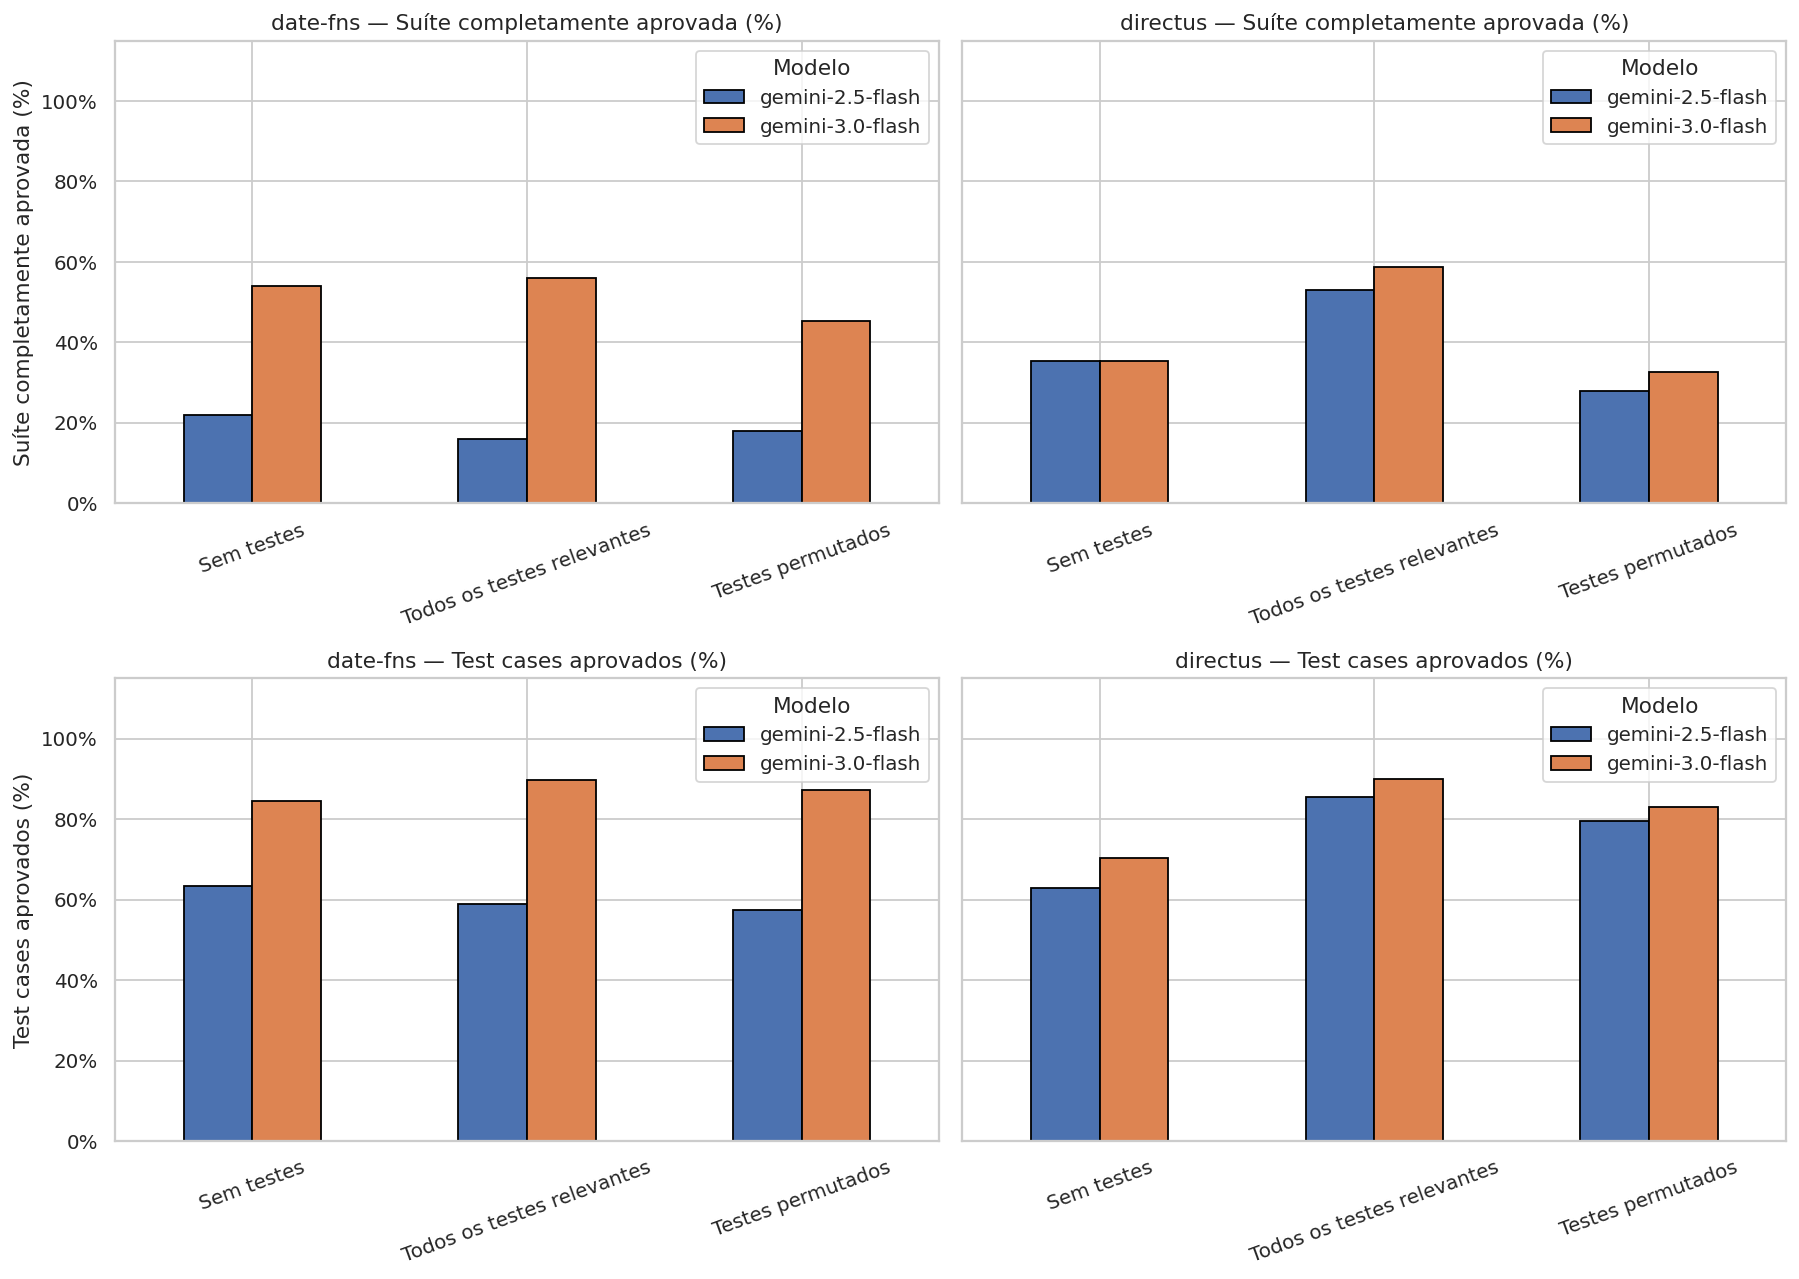

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for row, (metric_col, metric_label) in enumerate(METRICS):
    for col, repo in enumerate(df["repositoryName"].dropna().unique()):
        ax = axes[row][col]
        subset = df[df["repositoryName"] == repo]
        rates = (
            subset.groupby(["contextType", "model"])[metric_col]
            .mean()
            .unstack("model")
            .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
        )
        rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
        rates = rates * 100
        rates.plot(kind="bar", ax=ax, edgecolor="black")
        ax.set_title(f"{repo} — {metric_label}")
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 115)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis="x", rotation=20)
        ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("success_by_context_model.png", bbox_inches="tight")
plt.show()

### Suíte completamente aprovada por método, contexto e modelo

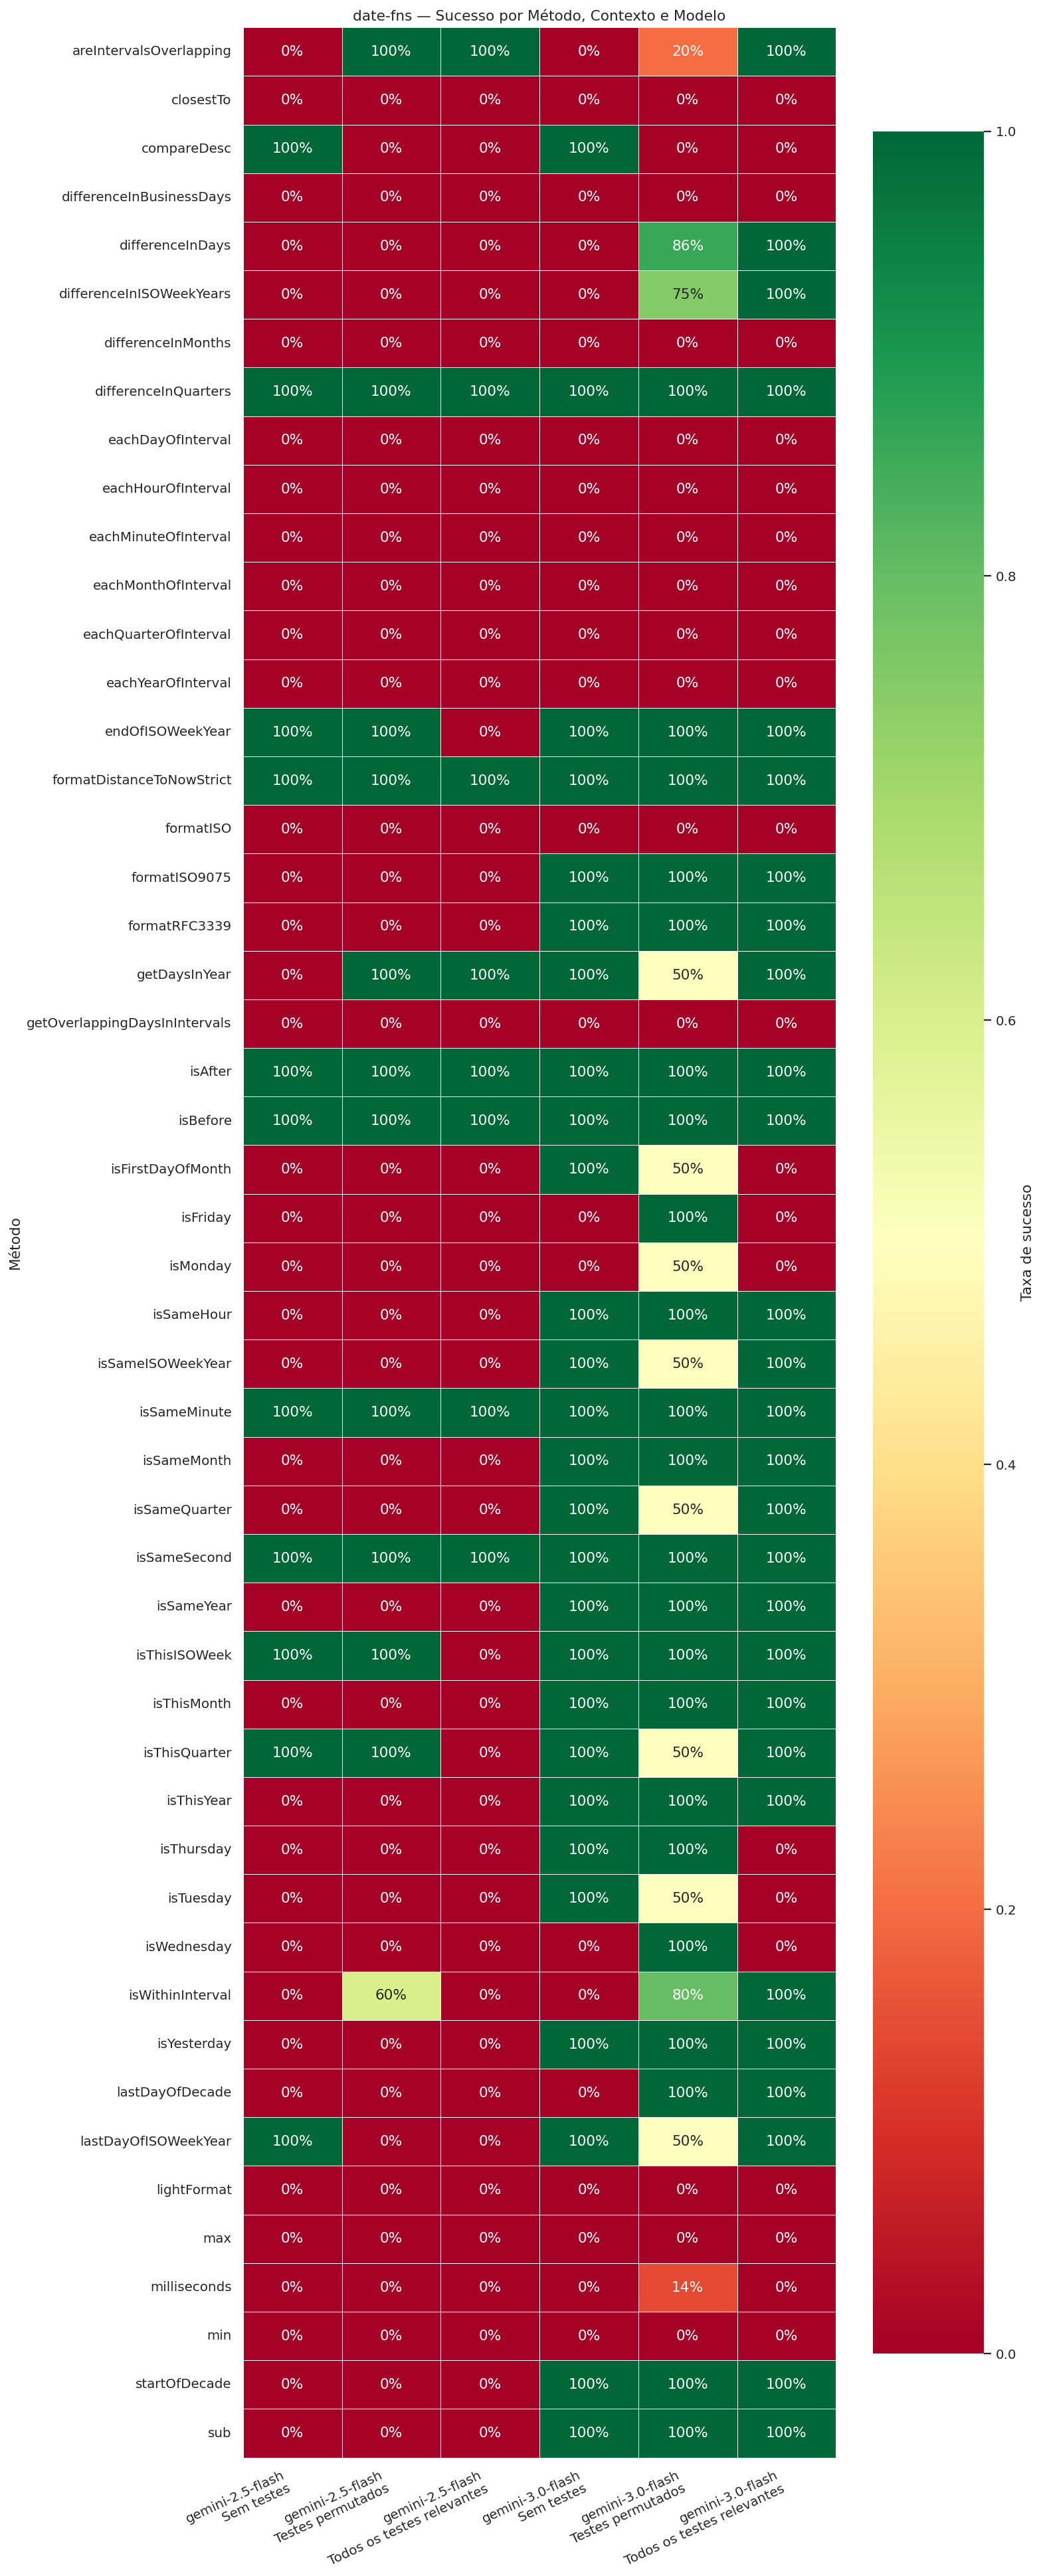

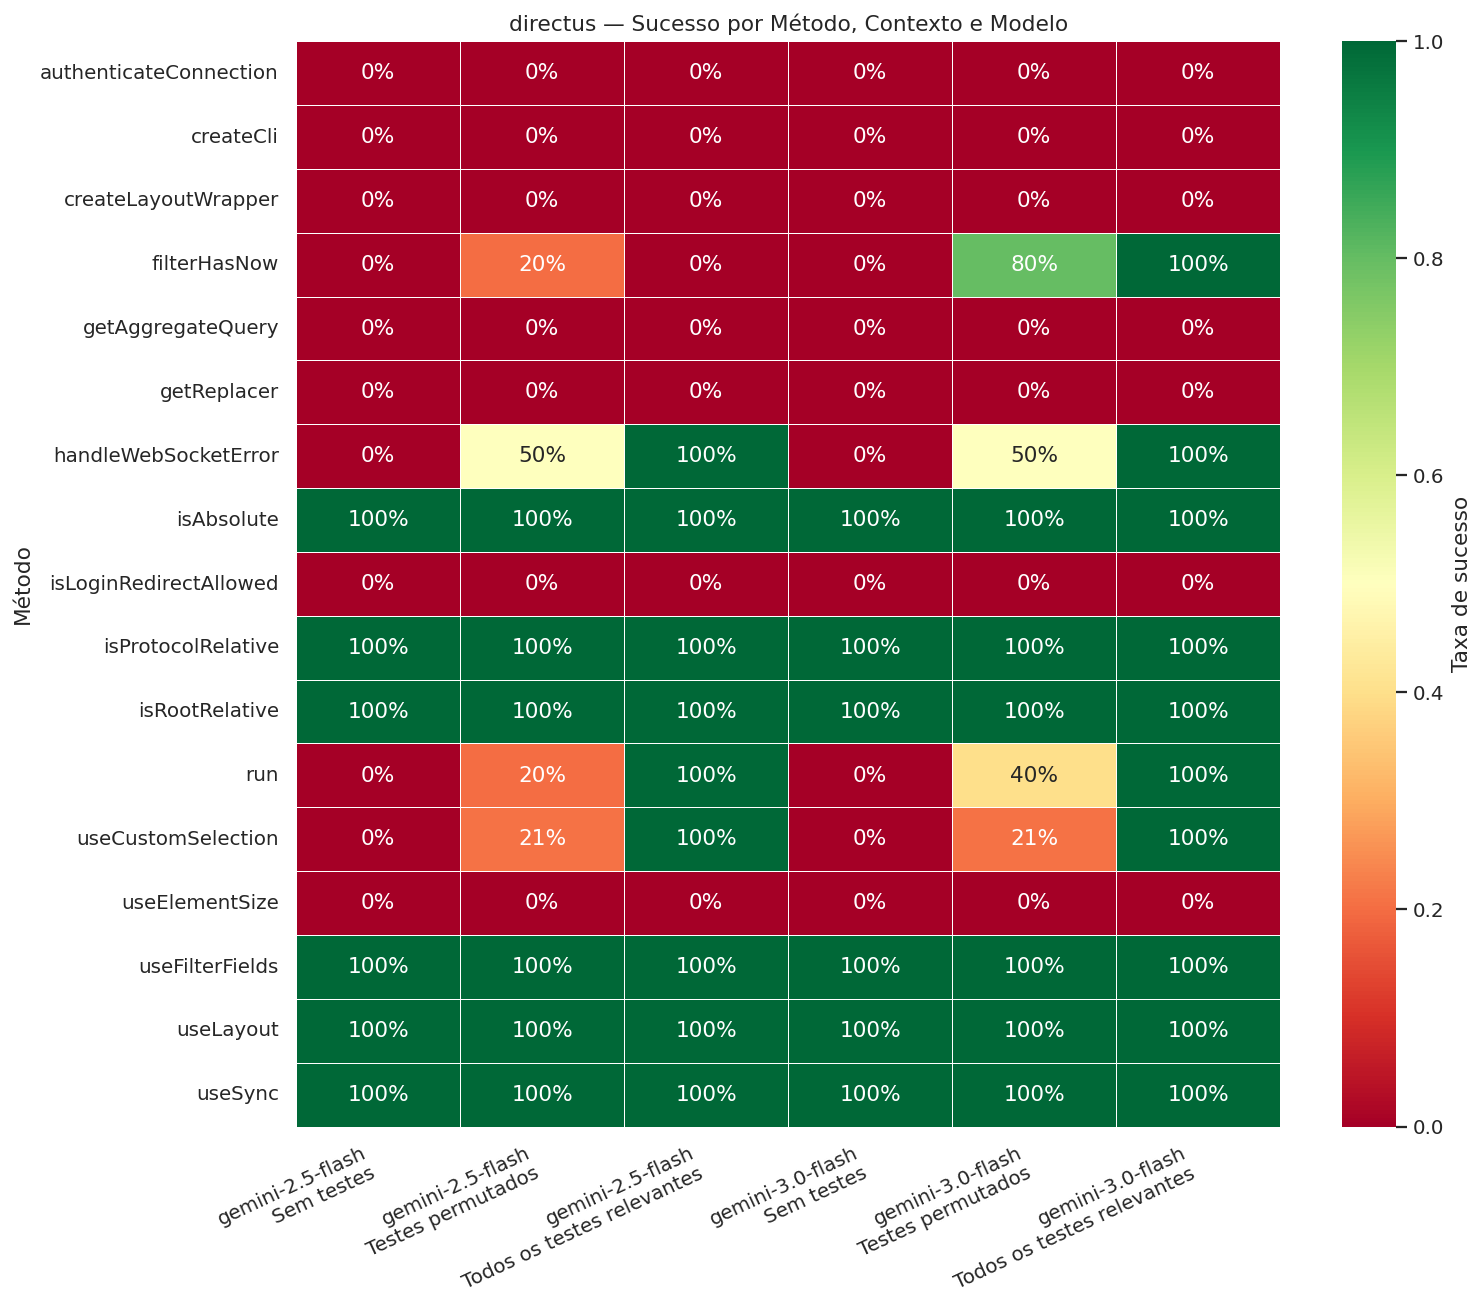

In [7]:
for repo in df["repositoryName"].dropna().unique():
    pivot = (
        df[df["repositoryName"] == repo]
        .groupby(["methodName", "contextType", "model"])["isTestSuiteSuccessful"]
        .mean()
        .reset_index()
        .assign(col=lambda d: d["model"] + "\n" + d["contextType"].map(CONTEXT_LABELS).fillna(d["contextType"]))
        .pivot(index="methodName", columns="col", values="isTestSuiteSuccessful")
        .fillna(np.nan)
    )
    plt.figure(figsize=(max(8, len(pivot.columns) * 2), max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": "Taxa de sucesso"})
    plt.title(f"{repo} — Sucesso por Método, Contexto e Modelo")
    plt.xlabel("")
    plt.ylabel("Método")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(f"heatmap_method_{repo}.png", bbox_inches="tight")
    plt.show()

### Compilabilidade por tipo de contexto e modelo

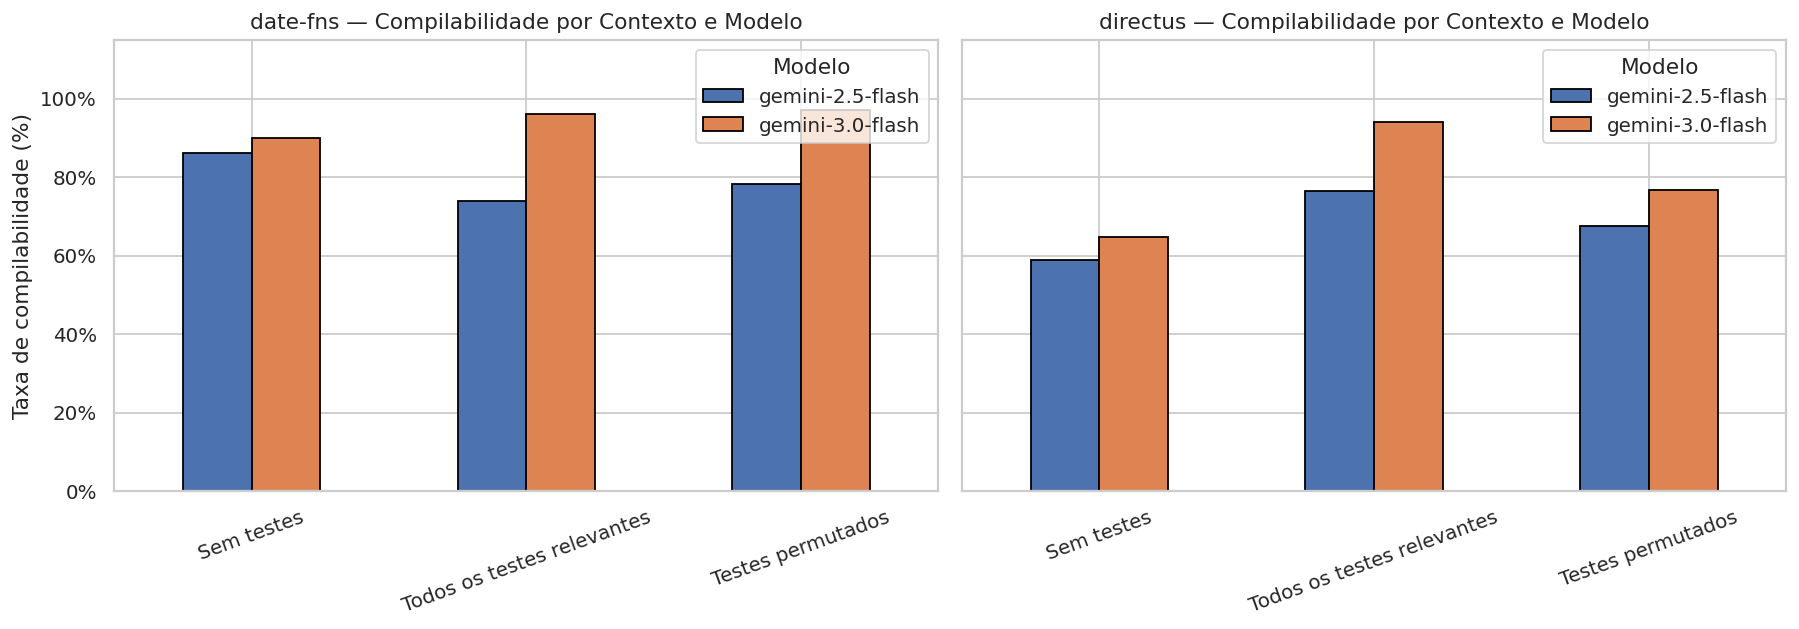

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, df["repositoryName"].dropna().unique()):
    subset = df[df["repositoryName"] == repo]
    rates = (
        subset.groupby(["contextType", "model"])["isModelResultCompilable"]
        .mean()
        .unstack("model")
        .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
    )
    rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
    rates = rates * 100
    rates.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(f"{repo} — Compilabilidade por Contexto e Modelo")
    ax.set_ylabel("Taxa de compilabilidade (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("compilable_by_context_model.png", bbox_inches="tight")
plt.show()

### Impacto do número de testes relevantes no pass rate

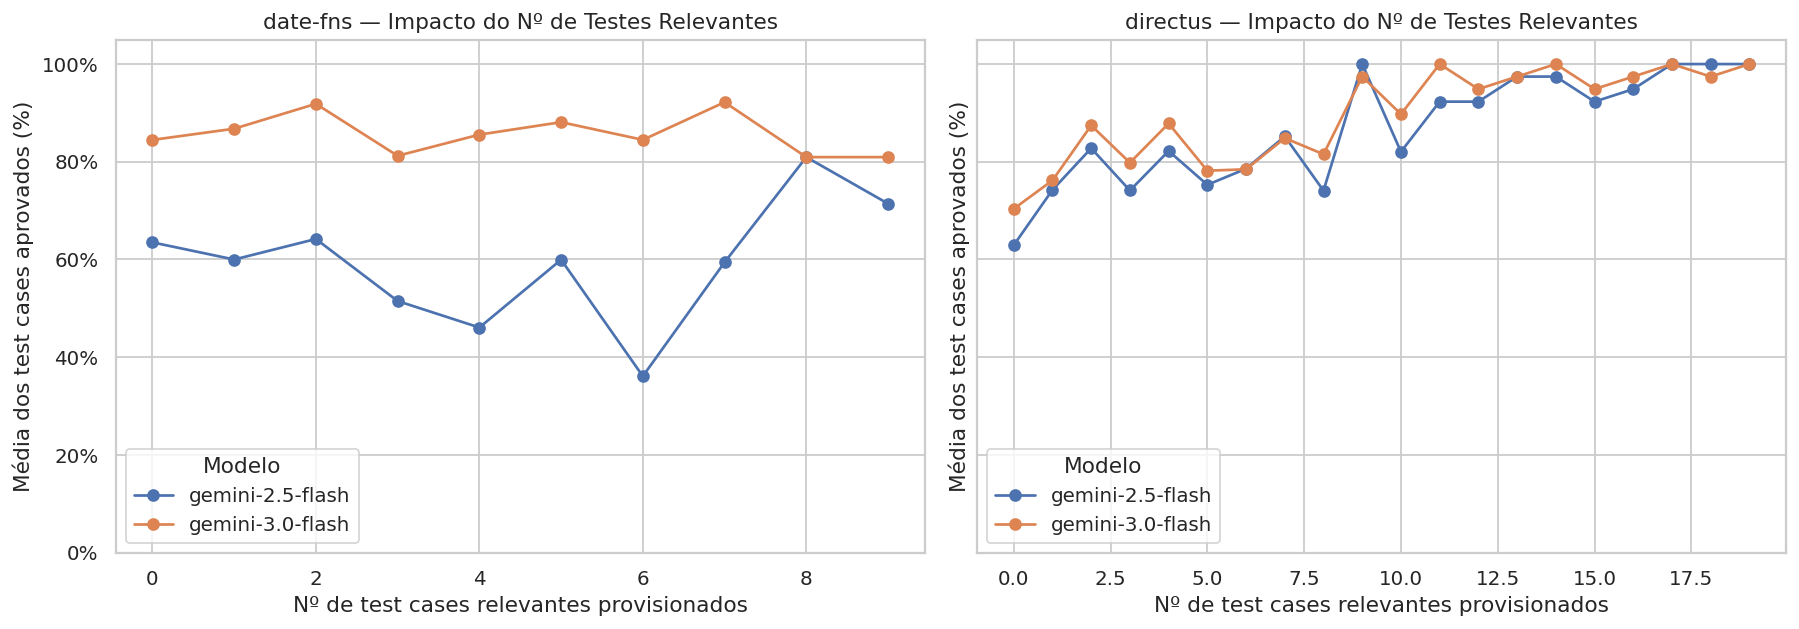

In [9]:
impact = (
    df.assign(testCasePassRateClamped=df["testCasePassRate"].clip(0, 1))
    .groupby(["repositoryName", "relevantTestCaseCount", "model"])["testCasePassRateClamped"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, df["repositoryName"].dropna().unique()):
    d = impact[impact["repositoryName"] == repo]
    for model_name, group in d.groupby("model"):
        group = group.sort_values("relevantTestCaseCount")
        ax.plot(group["relevantTestCaseCount"], group["testCasePassRateClamped"] * 100,
                marker="o", label=model_name)
    ax.set_title(f"{repo} — Impacto do Nº de Testes Relevantes")
    ax.set_xlabel("Nº de test cases relevantes provisionados")
    ax.set_ylabel("Média dos test cases aprovados (%)")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("impact_relevant_test_count.png", bbox_inches="tight")
plt.show()

## Análise em Linguagem Natural

### Setup do Agente

In [10]:
import os
from dotenv import load_dotenv
from google import genai
from pandasai import Agent
from pandasai.llm.base import LLM

load_dotenv("../.env")

class GoogleGenAILLM(LLM):
    def __init__(self, model: str, api_key: str):
        self.model = model
        self._client = genai.Client(api_key=api_key)

    def call(self, instruction, context=None):
        self.last_prompt = instruction.to_string()
        response = self._client.models.generate_content(
            model=self.model,
            contents=self.last_prompt,
        )
        return response.text

    @property
    def type(self) -> str:
        return "google-genai"

llm = GoogleGenAILLM(model="gemini-3-flash-preview", api_key=os.environ["GOOGLE_GENERATIVE_AI_API_KEY"])
agent = Agent([df], config={"llm": llm, "verbose": False, "custom_whitelisted_dependencies": ["os"], "open_charts": False})

In [11]:
from IPython.display import display, Markdown, Image
import os

def show_agent_result(result):
    if isinstance(result, str) and os.path.isfile(result):
        display(Image(filename=result))
    elif isinstance(result, str):
        display(Markdown(result))
    else:
        display(result)


### Perguntas para o Agente

In [12]:
questions = [
    # "Quais métodos foram reconstruídos com sucesso em todos os contextos testados?",
    # "Quais métodos nunca foram reconstruídos com sucesso, independente do contexto ou modelo?",
    # "Resuma os principais achados do experimento em tópicos.",
    # "Existe algum padrão claro que indique quando o contexto de testes ajuda e quando não ajuda?"
]

for question in questions:
    display(Markdown(f"---\n### {question}"))
    show_agent_result(agent.chat(question))

# 5. Perguntas de Pesquisa

## RQ1: Qual a relevância dos testes de unidade para geração de métodos?

### Gráfico: Taxa de sucesso/aprovação x Tipo de contexto

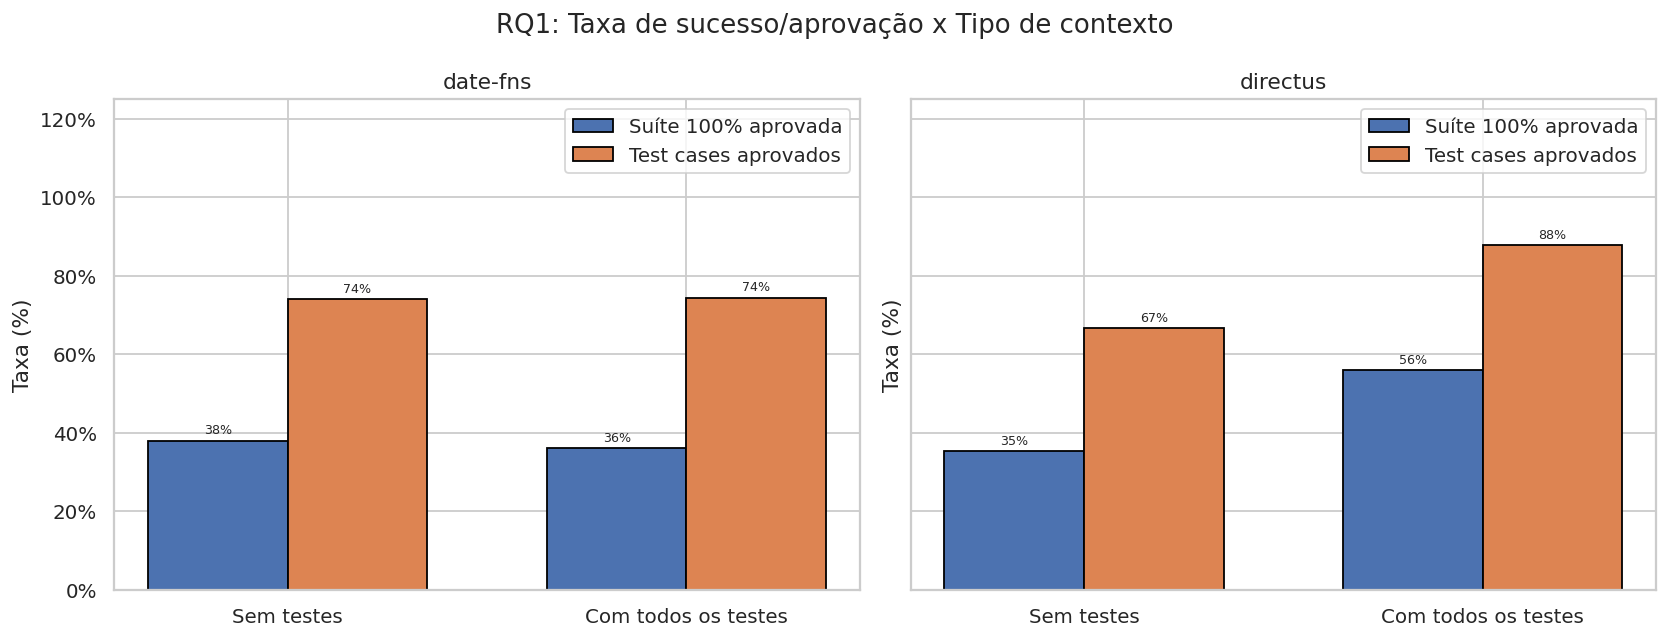

In [13]:
from scipy.stats import fisher_exact

rq1_contexts = ["no-relevant-test-case", "all-relevant-test-case"]
rq1_labels   = {"no-relevant-test-case": "Sem testes", "all-relevant-test-case": "Com todos os testes"}

subset = df[df["contextType"].isin(rq1_contexts)].copy()
subset["contextLabel"] = subset["contextType"].map(rq1_labels)

metrics = [("isTestSuiteSuccessful", "Suíte 100% aprovada"), ("testCasePassRate", "Test cases aprovados")]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, repo in zip(axes, df["repositoryName"].unique()):
    d = subset[subset["repositoryName"] == repo]
    labels = list(rq1_labels.values())
    x = np.arange(len(labels))
    width = 0.35

    for i, (col, name) in enumerate(metrics):
        means = [d[d["contextLabel"] == l][col].mean() * 100 for l in labels]
        ns    = [len(d[d["contextLabel"] == l]) for l in labels]
        bars  = ax.bar(x + i * width, means, width, label=name, edgecolor="black")
        for bar, n, val in zip(bars, ns, means):
            ax.annotate(f"{val:.0f}%",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1),
                        ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(labels)
    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa (%)")
    ax.set_ylim(0, 125)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()

plt.suptitle("RQ1: Taxa de sucesso/aprovação x Tipo de contexto")
plt.tight_layout()
plt.savefig("figures/rq1_context_vs_no_context.png", bbox_inches="tight")
plt.show()

### Gráfico: Taxa de sucesso/aprovação x Quantidade de testes no contexto

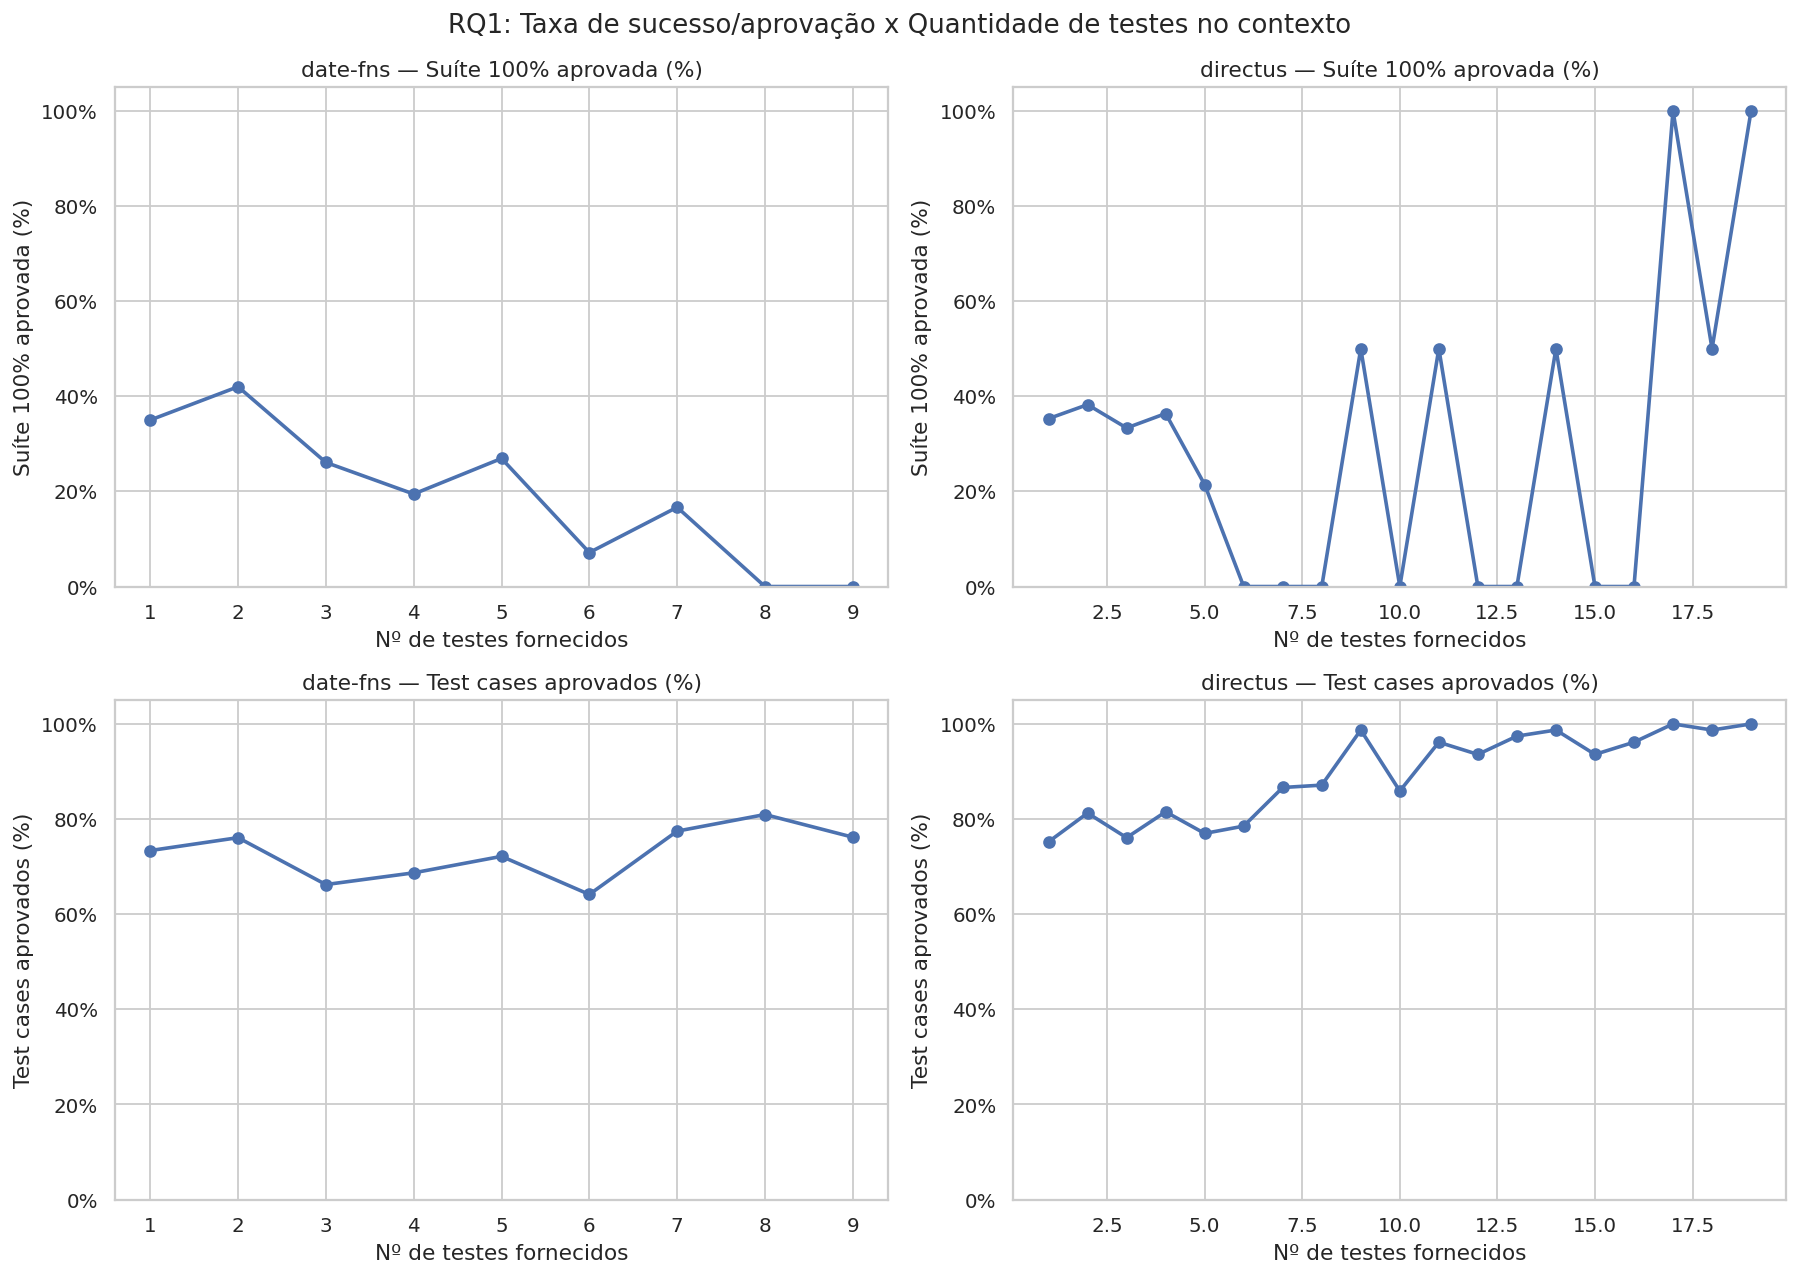

In [14]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, (metric_col, metric_label) in enumerate([
    ("isTestSuiteSuccessful", "Suíte 100% aprovada (%)"),
    ("testCasePassRate",      "Test cases aprovados (%)"),
]):
    impact = (
        permuted.groupby(["repositoryName", "experimentContextItemCount"])[metric_col]
        .agg(["mean", "sem"])
        .reset_index()
    )

    for row_idx, repo in enumerate(df["repositoryName"].unique()):
        ax = axes[col_idx][row_idx]

        d = impact[impact["repositoryName"] == repo].sort_values("experimentContextItemCount")
        ax.plot(d["experimentContextItemCount"], d["mean"] * 100, marker="o", linewidth=2, label="Média")

        ax.set_title(f"{repo} — {metric_label}")
        ax.set_xlabel("Nº de testes fornecidos")
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("RQ1: Taxa de sucesso/aprovação x Quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq1_test_count_vs_success.png", bbox_inches="tight")
plt.show()

### Gráfico: Taxa de aprovação por método × Quantidade de testes no contexto

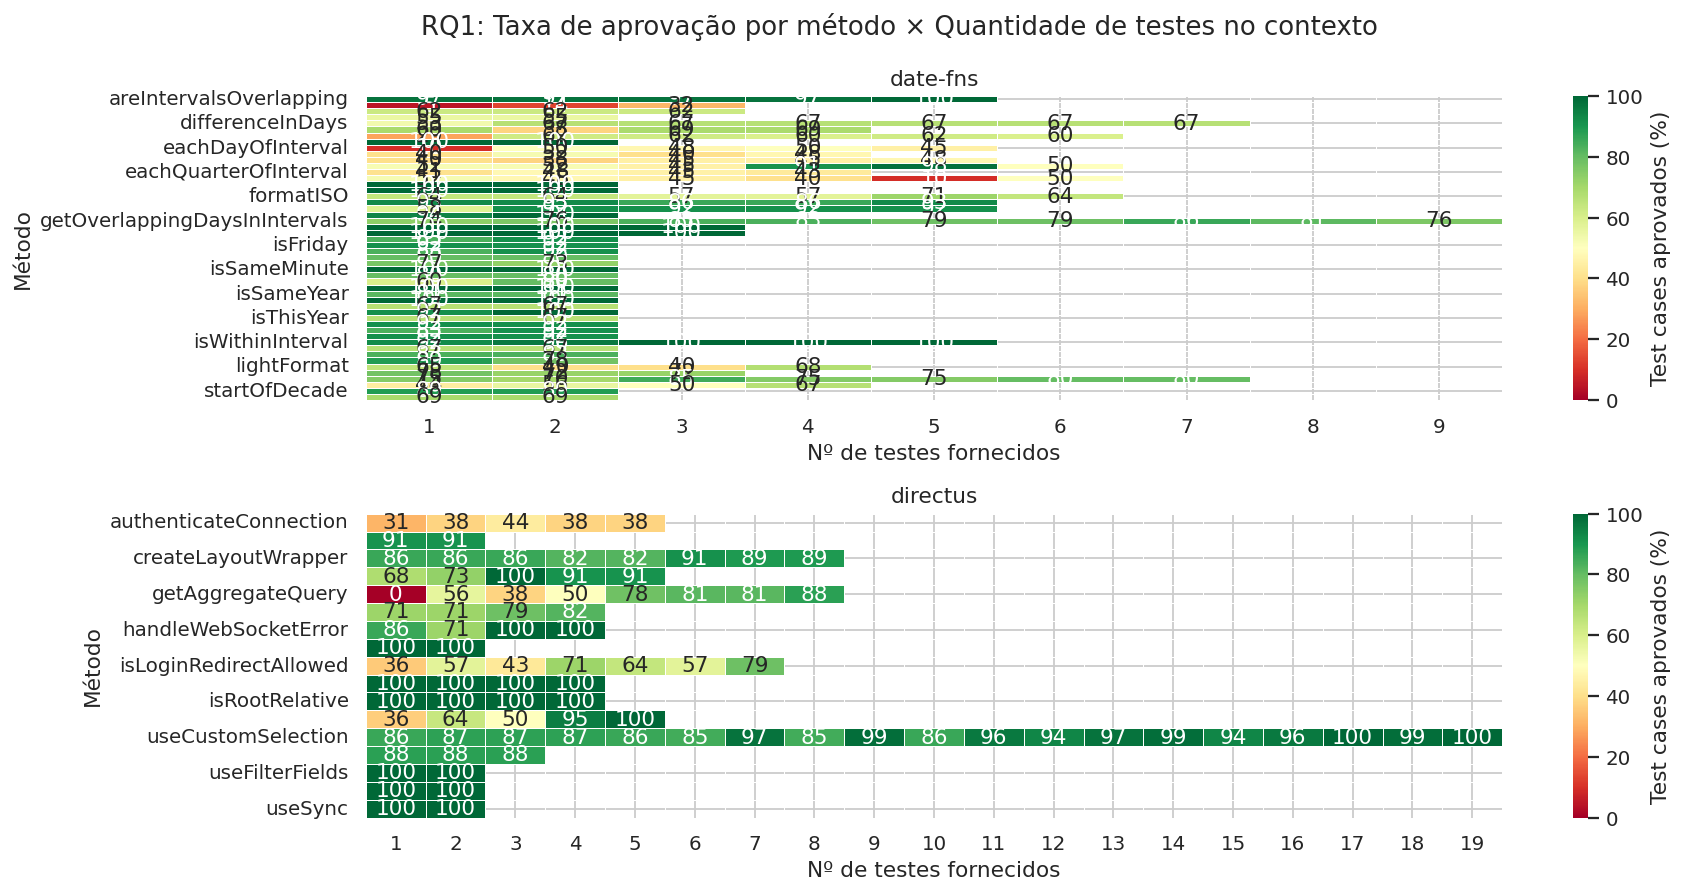

In [15]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, repo in zip(axes, permuted["repositoryName"].unique()):
    d = permuted[permuted["repositoryName"] == repo]
    pivot = (
        d.groupby(["methodName", "experimentContextItemCount"])["testCasePassRate"]
        .mean()
        .unstack("experimentContextItemCount")
        .sort_index()
    )
    sns.heatmap(pivot * 100, ax=ax, cmap="RdYlGn", vmin=0, vmax=100,
                annot=True, fmt=".0f", linewidths=0.3,
                cbar_kws={"label": "Test cases aprovados (%)"})
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes fornecidos")
    ax.set_ylabel("Método")

plt.suptitle("RQ1: Taxa de aprovação por método × Quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq1_method_heatmap.png", bbox_inches="tight")
plt.show()

## RQ2: Quais tipos de testes contribuem mais?

### Gráfico: Taxa de aprovação por método para diferentes estratégias de contexto

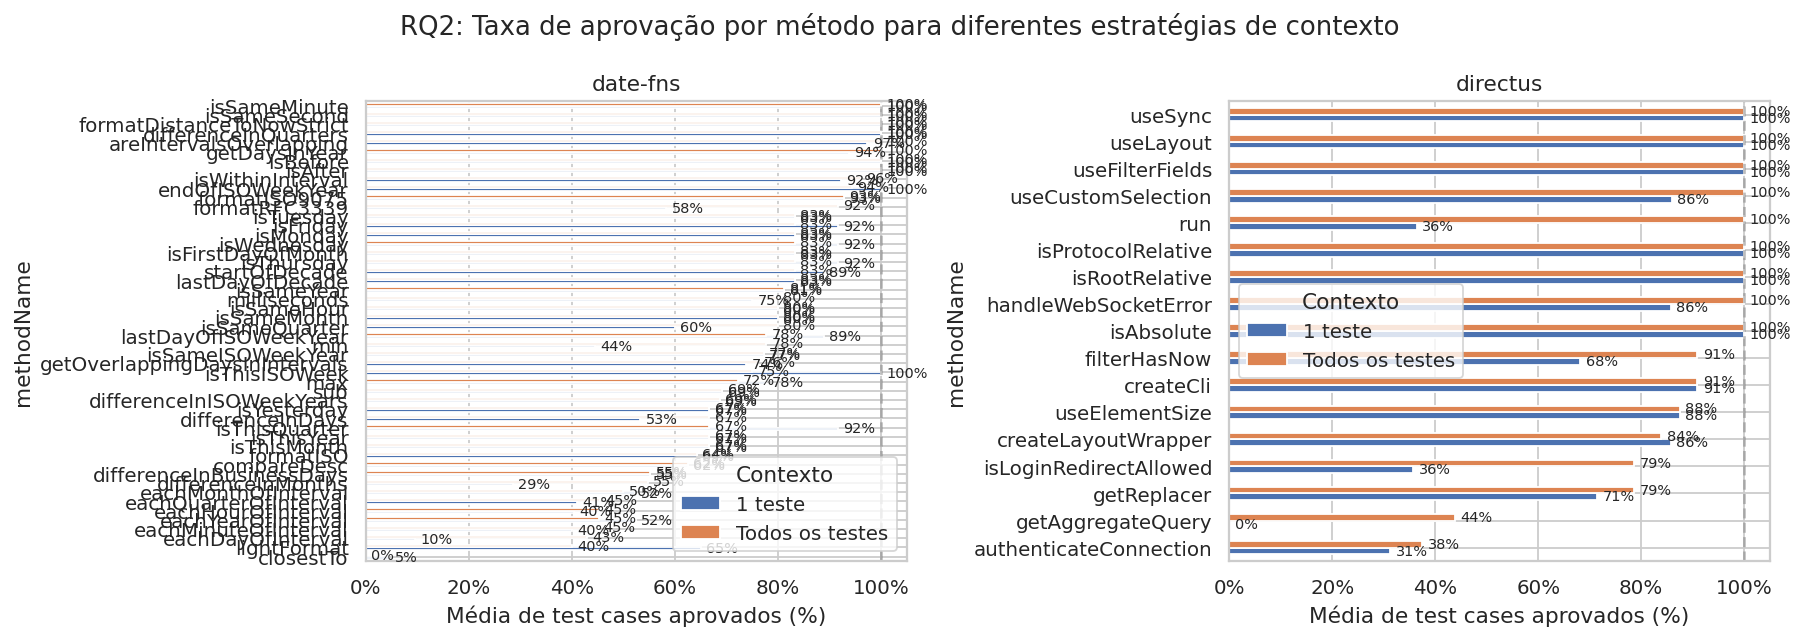

In [16]:
full_ctx = (
    df[df["contextType"] == "all-relevant-test-case"]
    .groupby(["repositoryName", "methodName"])["testCasePassRate"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
full_ctx["scenario"] = "Todos os testes"

single_ctx = (
    df[
        (df["contextType"] == "permuted-relevant-test-case") &
        (df["experimentContextItemCount"] == 1)
    ]
    .groupby(["repositoryName", "methodName"])["testCasePassRate"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
single_ctx["scenario"] = "1 teste"

rates = pd.concat([full_ctx, single_ctx], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, repo in zip(axes, rates["repositoryName"].unique()):

    d = rates[rates["repositoryName"] == repo].copy()

    pivot = (
        d.pivot(
            index="methodName",
            columns="scenario",
            values="mean"
        )
        * 100
    )

    pivot = pivot.sort_values(
        by="Todos os testes",
        ascending=True
    )

    bars = pivot.plot(
        kind="barh",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f%%",
            padding=3,
            fontsize=8
        )

    ax.set_title(f"{repo}")
    ax.set_xlabel("Média de test cases aprovados (%)")
    ax.axvline(100, linestyle="--", color="gray", alpha=0.5)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Contexto")

plt.suptitle(
    "RQ2: Taxa de aprovação por método para diferentes estratégias de contexto"
)

plt.tight_layout()
plt.savefig(
    "figures/rq2_context_comparison_by_method.png",
    bbox_inches="tight"
)
plt.show()

### Gráfico: Taxa de aprovação x Tipo de estrutura do teste

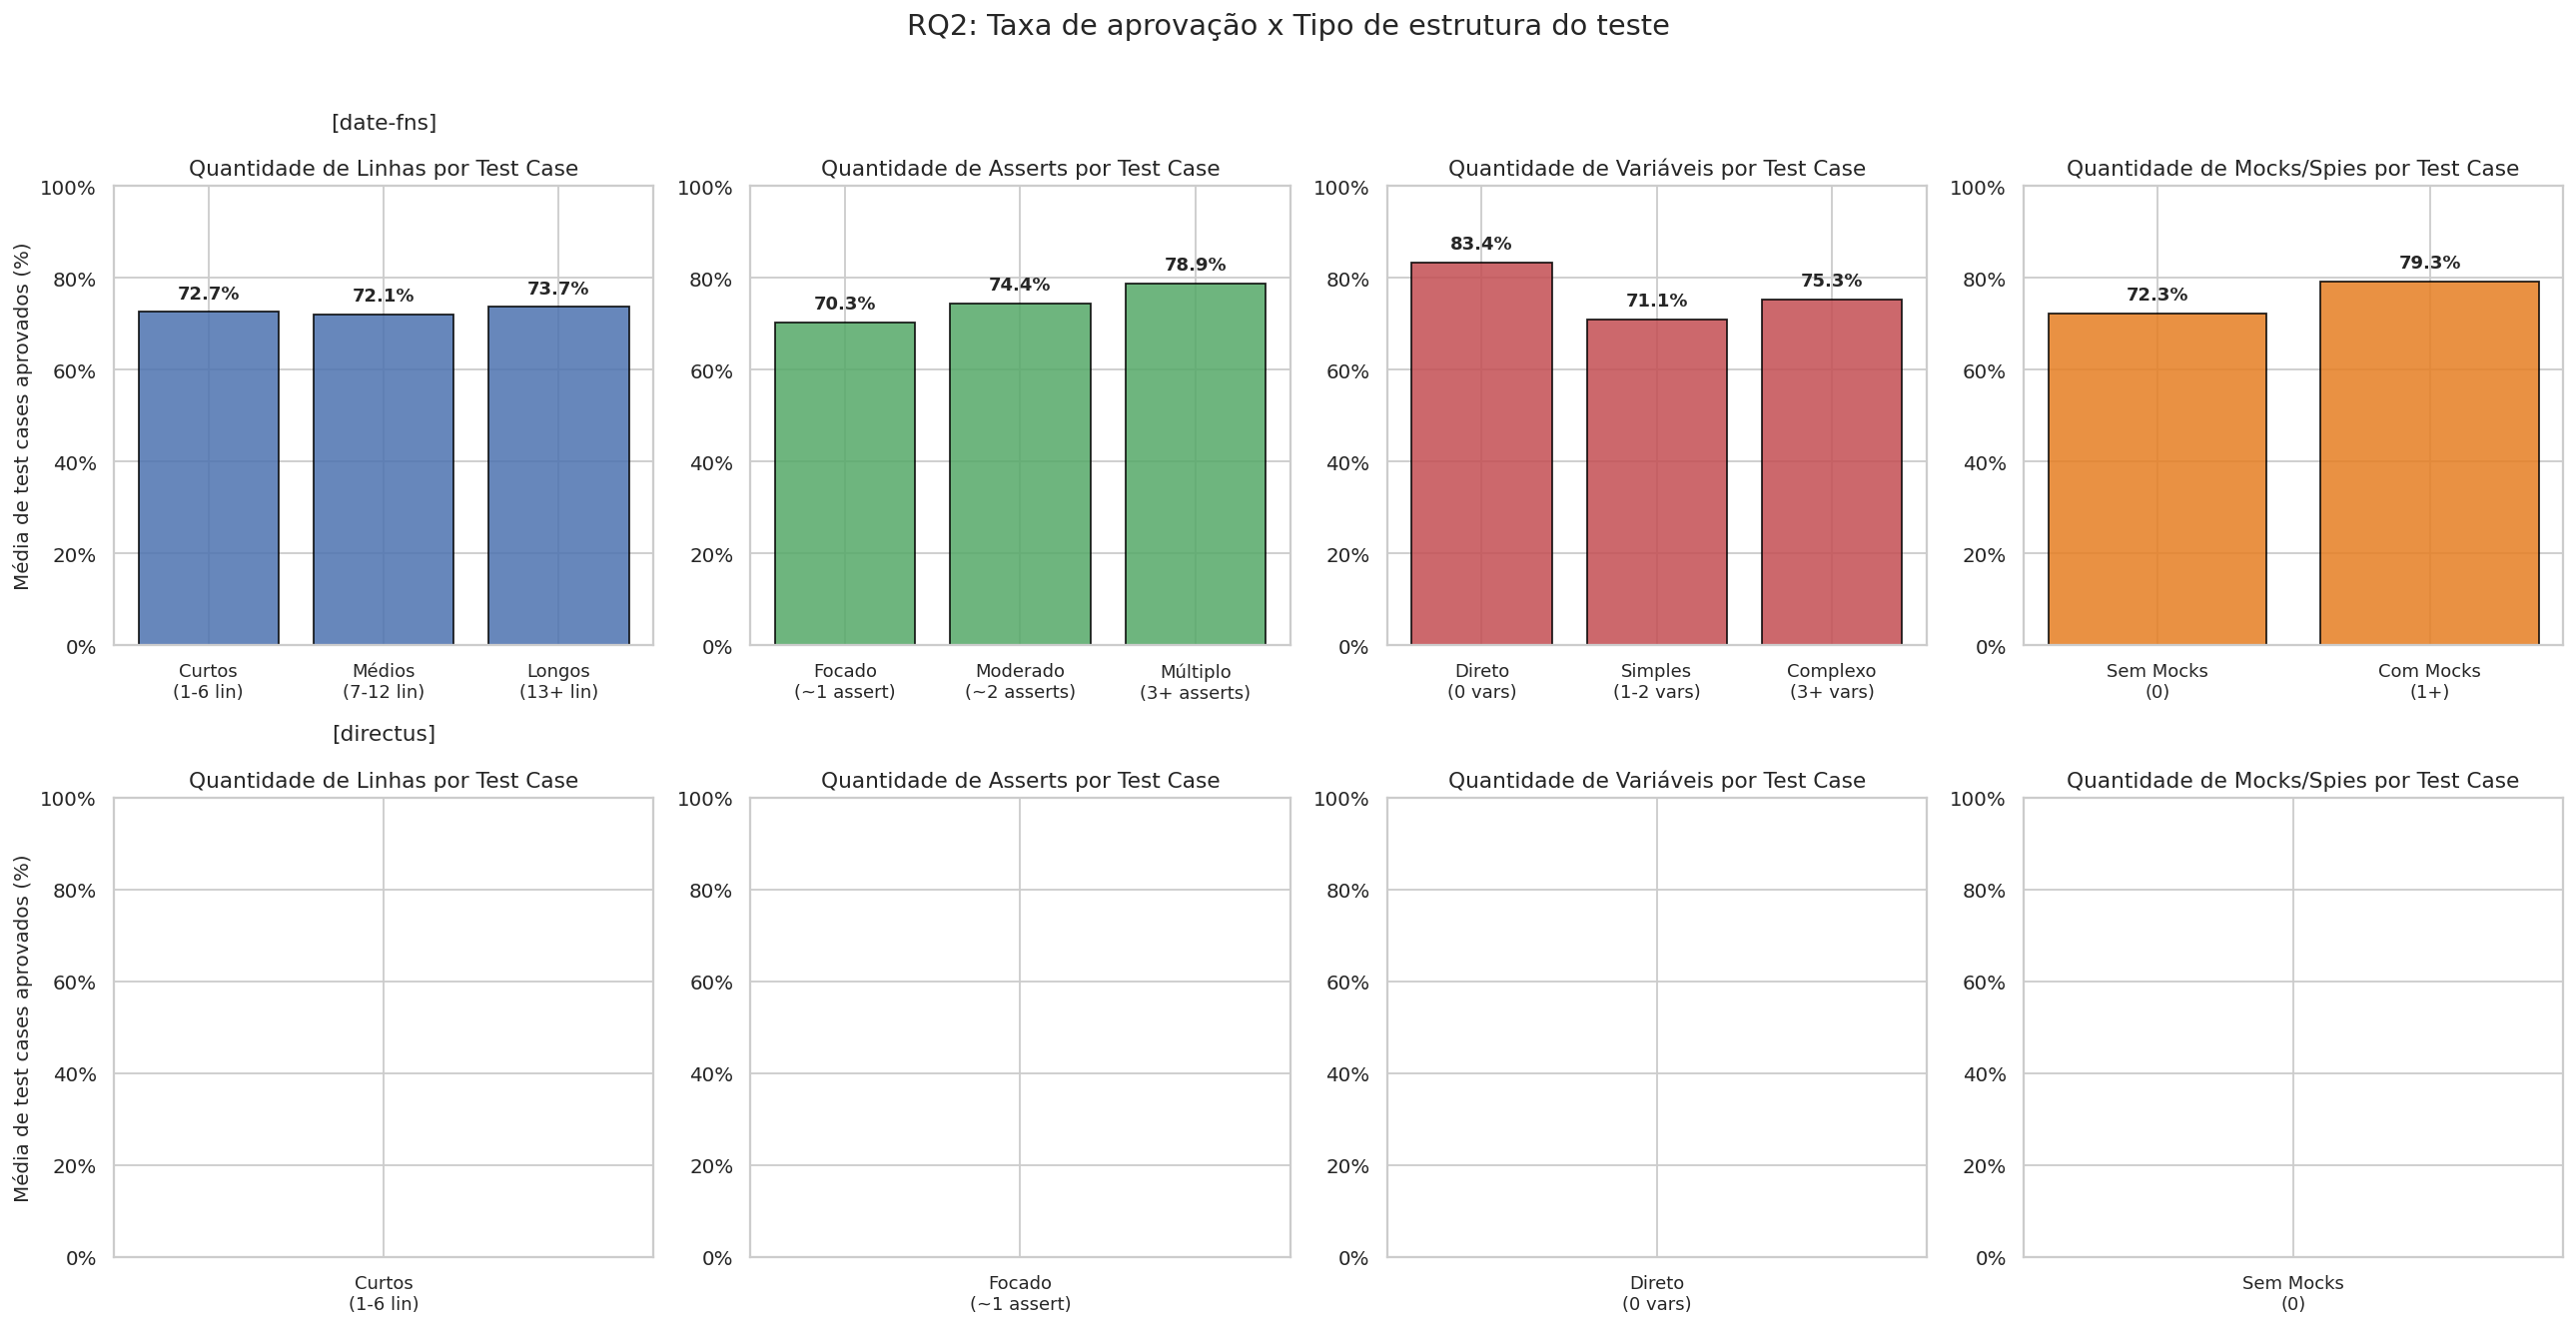

In [17]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def extract_structural_metrics(prompt_json):
    try:
        prompt = json.loads(prompt_json)
    except Exception:
        prompt = prompt_json
        
    text = prompt if isinstance(prompt, str) else str(prompt)
    
    test_blocks = re.findall(r"## relevant-test-case.*?```(?:typescript|ts|js)?\n(.*?)```", text, re.DOTALL)
    
    if not test_blocks:
        return {"avg_lines": 0, "avg_assertions": 0, "avg_vars": 0, "avg_mocks": 0}
    
    lines_per_block = [block.strip().count("\n") + 1 for block in test_blocks]
    assertions_per_block = [len(re.findall(r"\bexpect\(|\bassert\b|\bshould\b", block)) for block in test_blocks]
    vars_per_block = [len(re.findall(r"\bconst\b|\blet\b|\bvar\b", block)) for block in test_blocks]
    mocks_per_block = [len(re.findall(r"\bjest\b|\bvi\b|\bmock\b|\bspyOn\b", block)) for block in test_blocks]
    
    return {
        "avg_lines": np.mean(lines_per_block),
        "avg_assertions": np.mean(assertions_per_block),
        "avg_vars": np.mean(vars_per_block),
        "avg_mocks": np.mean(mocks_per_block)
    }

metrics_df = df[df["contextType"] == "permuted-relevant-test-case"].copy()
extracted = metrics_df["modelUserPrompt"].apply(extract_structural_metrics)
metrics_df = metrics_df.join(pd.DataFrame(extracted.tolist()))

metrics_df['cat_linhas'] = pd.cut(
    metrics_df['avg_lines'], 
    bins=[0, 6, 12, 100], 
    labels=['Curtos\n(1-6 lin)', 'Médios\n(7-12 lin)', 'Longos\n(13+ lin)']
)

metrics_df['cat_assertions'] = pd.cut(
    metrics_df['avg_assertions'], 
    bins=[0, 1.2, 2.5, 100], 
    labels=['Focado\n(~1 assert)', 'Moderado\n(~2 asserts)', 'Múltiplo\n(3+ asserts)']
)

metrics_df['cat_vars'] = pd.cut(
    metrics_df['avg_vars'], 
    bins=[-1, 0.5, 2.5, 100], 
    labels=['Direto\n(0 vars)', 'Simples\n(1-2 vars)', 'Complexo\n(3+ vars)']
)

metrics_df['cat_mocks'] = pd.cut(
    metrics_df['avg_mocks'], 
    bins=[-1, 0.5, 100], 
    labels=['Sem Mocks\n(0)', 'Com Mocks\n(1+)']
)

repos = metrics_df["repositoryName"].unique()

configs = [
    {'col': 'cat_linhas', 'title': 'Quantidade de Linhas por Test Case', 'color': '#4C72B0'},
    {'col': 'cat_assertions', 'title': 'Quantidade de Asserts por Test Case', 'color': '#55A868'},
    {'col': 'cat_vars', 'title': 'Quantidade de Variáveis por Test Case', 'color': '#C44E52'},
    {'col': 'cat_mocks', 'title': 'Quantidade de Mocks/Spies por Test Case', 'color': '#E67E22'}
]

fig, axes = plt.subplots(len(repos), len(configs), figsize=(20, 5 * len(repos)))

if len(repos) == 1:
    axes = [axes]

for row_idx, repo in enumerate(repos):
    d = metrics_df[metrics_df["repositoryName"] == repo]
    
    for col_idx, config in enumerate(configs):
        ax = axes[row_idx][col_idx]
        
        media = d.groupby(config['col'], observed=False)['testCasePassRate'].mean() * 100
        
        bars = ax.bar(media.index, media.values, color=config['color'], edgecolor='black', alpha=0.85)

        repo_title = f"[{repo}]\n\n" if col_idx == 0 else ""
        ax.set_title(f"{repo_title}{config['title']}", fontsize=12)
        
        if col_idx == 0:
            ax.set_ylabel("Média de test cases aprovados (%)", fontsize=11)
            
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis='x', labelsize=10)
        
        for bar in bars:
            yval = bar.get_height()
            if not np.isnan(yval) and yval > 0:
                ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", 
                        ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle("RQ2: Taxa de aprovação x Tipo de estrutura do teste", fontsize=16, y=1.05 if len(repos)==1 else 1.02)
plt.tight_layout()
plt.savefig("figures/rq2_internal_structure_analysis.png", bbox_inches="tight")
plt.show()

## RQ3: Quais LLMs geram métodos de forma mais eficiente?

### Gráfico: Taxa de sucesso por modelo x Tipo de contexto

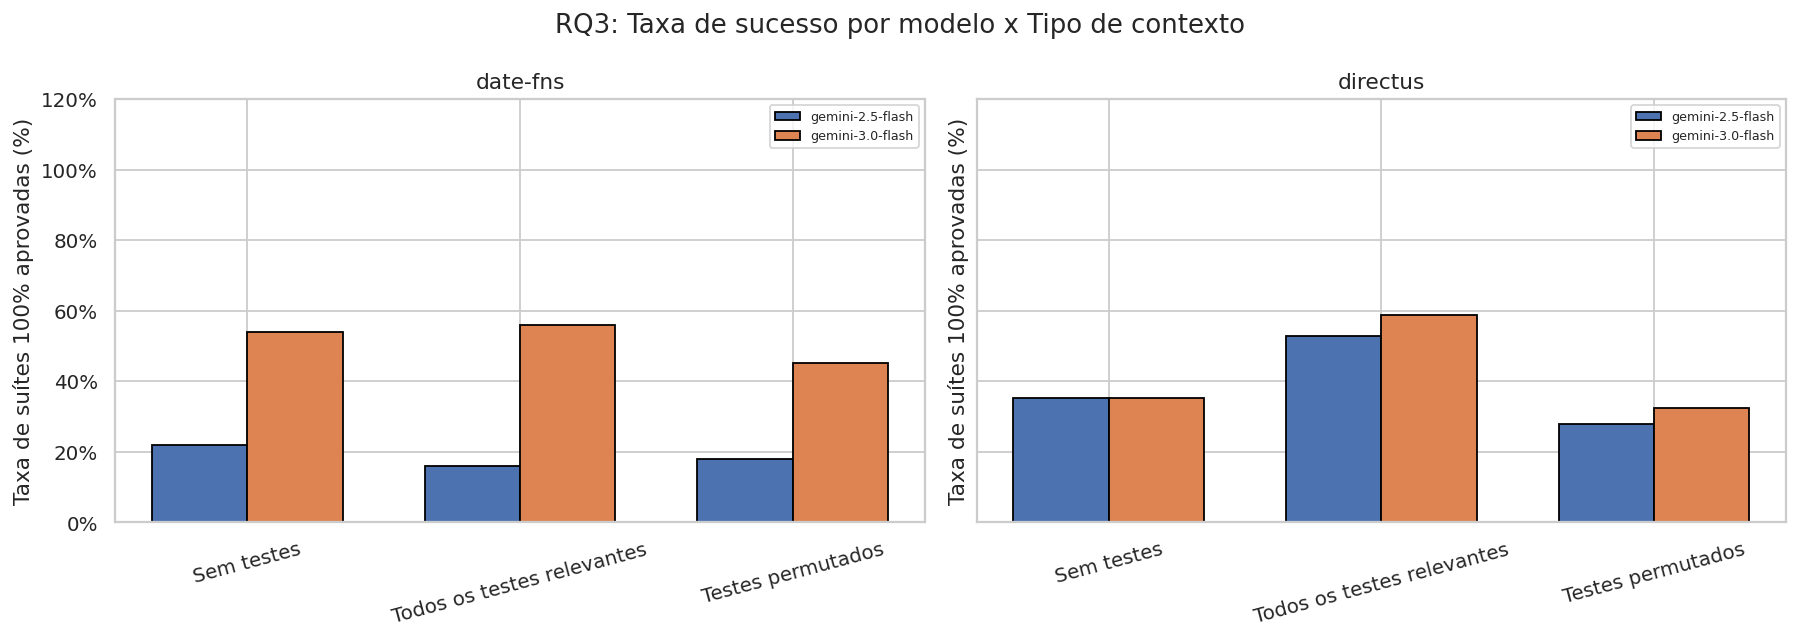

In [18]:
rates = (
    df.groupby(["repositoryName", "modelName", "contextType"])["isTestSuiteSuccessful"]
    .agg(["mean", "count"])
    .reset_index()
)
global_rates = df.groupby("modelName")["isTestSuiteSuccessful"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, repo in zip(axes, df["repositoryName"].unique()):
    d = rates[rates["repositoryName"] == repo]
    ordered  = [c for c in CONTEXT_ORDER if c in d["contextType"].values]
    models   = d["modelName"].unique()
    x        = np.arange(len(ordered))
    width    = 0.35

    for i, model in enumerate(models):
        dm   = d[d["modelName"] == model].set_index("contextType").reindex(ordered, fill_value=0)
        bars = ax.bar(x + i * width, dm["mean"] * 100, width, label=model, edgecolor="black")

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([CONTEXT_LABELS.get(c, c) for c in ordered], rotation=15)
    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa de suítes 100% aprovadas (%)")
    ax.set_ylim(0, 120)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=7)

plt.suptitle("RQ3: Taxa de sucesso por modelo x Tipo de contexto")
plt.tight_layout()
plt.savefig("figures/rq3_model_vs_context.png", bbox_inches="tight")
plt.show()

### Gráfico: Taxa de compilabilidade por modelo

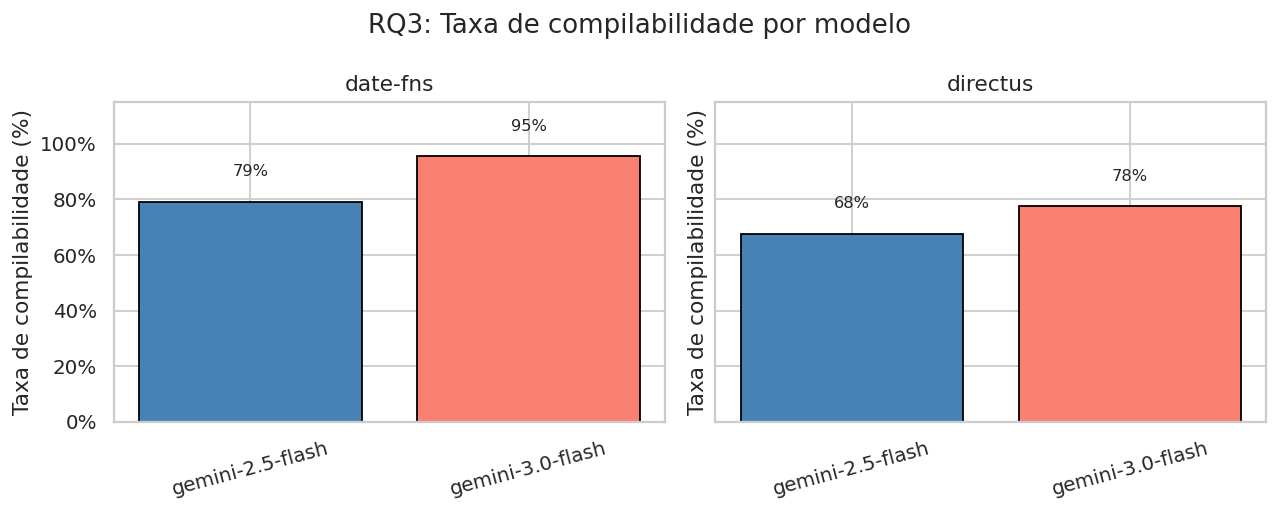

In [19]:
from scipy.stats import norm as _norm

def wilson_ci(successes, n, confidence=0.95):
    z = _norm.ppf((1 + confidence) / 2)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - margin, center + margin

comp = (
    df.groupby(["repositoryName", "modelName"])["isModelResultCompilable"]
    .agg(["sum", "count"])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, repo in zip(axes, comp["repositoryName"].unique()):
    d = comp[comp["repositoryName"] == repo]
    means     = d["sum"] / d["count"]
    ci_bounds = [wilson_ci(s, n) for s, n in zip(d["sum"], d["count"])]
    yerr_low  = means - np.array([b[0] for b in ci_bounds])
    yerr_high = np.array([b[1] for b in ci_bounds]) - means

    bars = ax.bar(d["modelName"], means * 100, edgecolor="black", capsize=5, color=["steelblue", "salmon"])
    for bar, val, n in zip(bars, means, d["count"]):
        ax.annotate(f"{val*100:.0f}%\n",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2),
                    ha="center", va="bottom", fontsize=9)

    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa de compilabilidade (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("RQ3: Taxa de compilabilidade por modelo")
plt.tight_layout()
plt.savefig("figures/rq3_compilability_by_model.png", bbox_inches="tight")
plt.show()

### Gráfico: Comparação de modelo pareada da taxa de aprovação dos testes por método

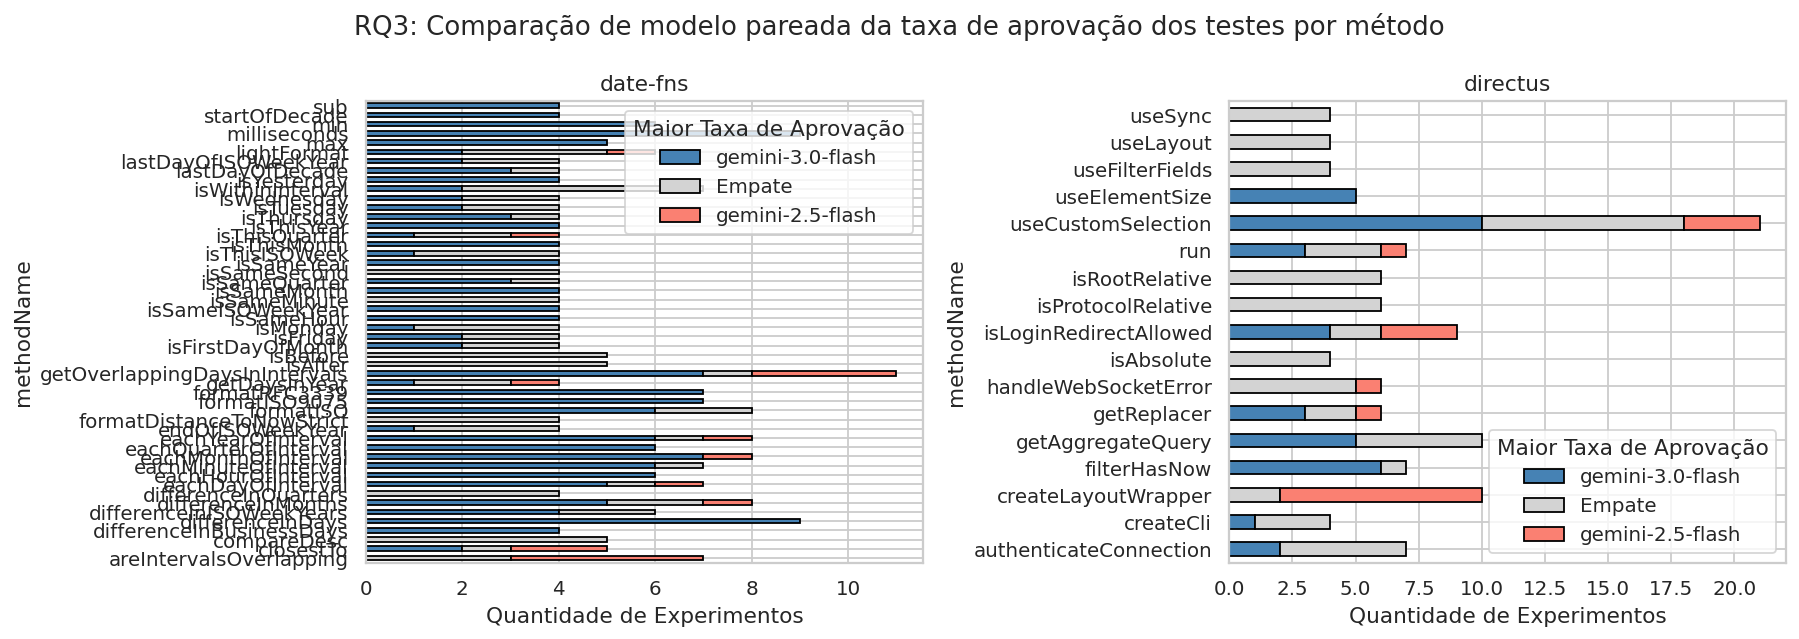

In [20]:
models = df["modelName"].unique()
if len(models) != 2:
    print("Essa análise requer exatamente 2 modelos no dataset.")
else:
    m0, m1 = models[0], models[1]

    left  = df[df["modelName"] == m0][["repositoryName", "methodName", "contextType",
                                        "experimentContextItemCount", "testCasePassRate"]]
    right = df[df["modelName"] == m1][["repositoryName", "methodName", "contextType",
                                        "experimentContextItemCount", "testCasePassRate"]]
    paired = left.merge(right,
                        on=["repositoryName", "methodName", "contextType", "experimentContextItemCount"],
                        suffixes=(f"_{m0}", f"_{m1}"))

    def outcome(row):
        a = row[f"testCasePassRate_{m0}"]
        b = row[f"testCasePassRate_{m1}"]
    
        if abs(a - b) < 0.01:
            return "Empate"
    
        return (
            f"{m1}"
            if b > a
            else f"{m0}"
        )
    
    paired["outcome"] = paired.apply(outcome, axis=1)
    
    summary = (
        paired.groupby(["repositoryName", "methodName", "outcome"])
        .size()
        .unstack("outcome", fill_value=0)
        .reset_index()
    )
    
    outcome_order = [
        f"{m1}",
        "Empate",
        f"{m0}"
    ]
    
    outcome_colors = {
        "Empate": "lightgray",
        f"{m1}": "steelblue",
        f"{m0}": "salmon"
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, repo in zip(axes, summary["repositoryName"].unique()):
        d     = summary[summary["repositoryName"] == repo].set_index("methodName")
        cols  = [c for c in outcome_order if c in d.columns]
        colors = [outcome_colors[c] for c in cols]
        d[cols].plot(kind="barh", stacked=True, ax=ax, color=colors, edgecolor="black")
        ax.set_title(f"{repo}")
        ax.set_xlabel("Quantidade de Experimentos")
        ax.legend(title="Maior Taxa de Aprovação")

    plt.suptitle(f"RQ3: Comparação de modelo pareada da taxa de aprovação dos testes por método")
    plt.tight_layout()
    plt.savefig("figures/rq3_win_loss_by_method.png", bbox_inches="tight")
    plt.show()